In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner

In [6]:
def generate_data(n):
    W = np.random.uniform(0, 1, n)
    # 1. Create a mixture selector (coin flip) for Y(1)
    mode_selector = np.random.binomial(1, 3/4, n)
    
    # 2. Define Y(0) and Y(1)
    y0 = np.random.normal(W / 2, 1, n)
    y1_mode_a = np.random.normal(W, 0.5, n)
    y1_mode_b = np.random.normal(2 + W, 0.5, n)
    y1 = np.where(mode_selector == 1, y1_mode_a, y1_mode_b)
    
    # 3. Treatment assignment
    probs = np.where(W > 0.5, 0.6, 0.4)
    X = (np.random.uniform(0, 1, n) < probs).astype(int)
    
    # 4. Observed Outcome
    Y_obs = np.where(X == 1, y1, y0)
    
    return Y_obs, X, W

def true_y0_density(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    
    # Y(0) ~ N(W/2, 1)
    mu = w_grid / 2
    dens = np.exp(-0.5 * ((y_vals[:, None] - mu[None, :]) / 1) ** 2) / (1 * np.sqrt(2 * np.pi))
    
    # Average over W
    return np.mean(dens, axis=1)


def true_y1_density(y_vals, n_w=200):
    w_grid = np.linspace(0, 1, n_w)
    
    # Mode A density
    mu_a = w_grid
    dens_a = np.exp(-0.5 * ((y_vals[:, None] - mu_a[None, :]) / 0.5) ** 2) / (0.5 * np.sqrt(2 * np.pi))
    
    # Mode B density
    mu_b = 2 + w_grid
    dens_b = np.exp(-0.5 * ((y_vals[:, None] - mu_b[None, :]) / 0.5) ** 2) / (0.5 * np.sqrt(2 * np.pi))
    
    # Total density is the average of both modes across all W
    return np.mean((3/4) * dens_a + (1/4) * dens_b, axis=1)

In [7]:
# load data
np.random.seed(42)
n = 200
y, x, w = generate_data(n)

# define parameters
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 50)
T_fwd, B_post = 1000, 100

# True density functions
true_y0 = true_y0_density(y_grid)
true_y1 = true_y1_density(y_grid)

# fit martingale posteriors and compute density estimates for S-Learner
res_s = mp_density(y, x, w, [0, 1], y_grid, B_post, T_fwd)
res_s_c, res_s_t = res_s['x_0'], res_s['x_1']

# fit martingale posteriors and compute density estimates for T-Learner
res_t = mp_density_t_learner(y, x, w, [0, 1], y_grid, B_post, T_fwd)
res_t_c, res_t_t = res_t['x_0'], res_t['x_1']



Compiling...
Compilation time: 0.113s
Optimizing...
Optimization time: 0.563s
Fitting...
Fit time: 0.014s
Optimised rho:  0.69451016
Optimised rho_x:  [0.86948675 0.33016878]
Prequential log-likelihhod:  -1.4507191181182861
Predicting...
Prediction time: 1.404s
Predictive resampling...
Predictive resampling time: 26.276s
Compiling...
Compilation time: 0.032s
Optimizing...
Optimization time: 0.181s
Fitting...
Fit time: 0.006s
Optimised rho for x=0:  0.11432504
Optimised rho_x for x=0:  [0.6629615 0.7265053]
Prequential log-likelihood for x=0:  -1.409890055656433
Predicting...
Prediction time: 0.282s
Predictive resampling...
Predictive resampling time: 5.884s
Compiling...
Compilation time: 0.029s
Optimizing...
Optimization time: 0.3s
Fitting...
Fit time: 0.006s
Optimised rho for x=1:  0.7685914
Optimised rho_x for x=1:  [0.00589893 0.5007767 ]
Prequential log-likelihood for x=1:  -1.385629415512085
Predicting...
Prediction time: 0.228s
Predictive resampling...
Predictive resampling time:

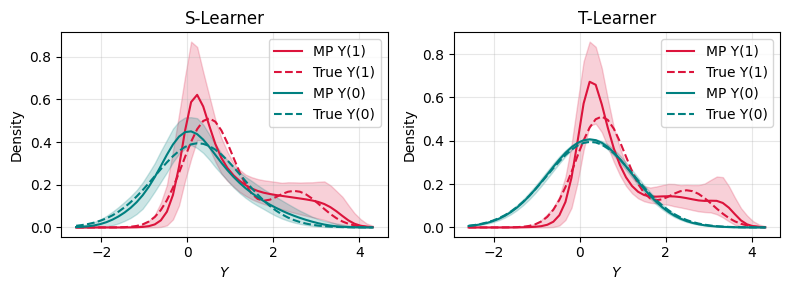

In [10]:

# plot results
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

# S-Learner plot
axs[0].plot(y_grid, res_s_t['mean'], color='crimson', label='MP Y(1)')
axs[0].fill_between(y_grid, res_s_t['low'], res_s_t['high'], color='crimson', alpha=0.2)
axs[0].plot(y_grid, true_y1, '--', color='crimson', label='True Y(1)')
axs[0].plot(y_grid, res_s_c['mean'], color='teal', label='MP Y(0)')
axs[0].fill_between(y_grid, res_s_c['low'], res_s_c['high'], color='teal', alpha=0.2)
axs[0].plot(y_grid, true_y0, '--', color='teal', label='True Y(0)')
axs[0].set_xlabel('$Y$')
axs[0].set_ylabel('Density')
axs[0].set_title('S-Learner')
axs[0].legend()
axs[0].grid(alpha=0.3)

# T-Learner plot
axs[1].plot(y_grid, res_t_t['mean'], color='crimson', label='MP Y(1)')
axs[1].fill_between(y_grid, res_t_t['low'], res_t_t['high'], color='crimson', alpha=0.2)
axs[1].plot(y_grid, true_y1, '--', color='crimson', label='True Y(1)')
axs[1].plot(y_grid, res_t_c['mean'], color='teal', label='MP Y(0)')
axs[1].fill_between(y_grid, res_t_c['low'], res_t_c['high'], color='teal', alpha=0.2)
axs[1].plot(y_grid, true_y0, '--', color='teal', label='True Y(0)')
axs[1].set_xlabel('$Y$')
axs[1].set_ylabel('Density')
axs[1].set_title('T-Learner')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/Density_Sim.pdf', dpi=300, bbox_inches='tight')
plt.show()